# Introduction au projet Building Perceptron

Ce projet s'inscrit dans le cadre d'une formation en Intelligence Artificielle et Data Science à La Plateforme_. Il vise à comprendre et mettre en œuvre le Perceptron, modèle fondamental en apprentissage automatique inventé par Frank Rosenblatt, qui constitue la base historique et conceptuelle des réseaux de neurones.

L’objectif principal est double : d’abord, développer une implémentation en Python du Perceptron à travers une approche orientée objet ; ensuite, appliquer ce modèle à un cas réel en utilisant le dataset Breast Cancer Wisconsin pour la classification binaire (diagnostic du cancer du sein, tumeur bénigne ou maligne).

Le projet se déroule en plusieurs phases intégrant une analyse exploratoire approfondie du dataset, une réduction de dimensionnalité pour optimiser les performances, puis l’entraînement et l’évaluation du Perceptron à l’aide de métriques adaptées au contexte médical.

Cette expérience permet à la fois d’acquérir des compétences pratiques en programmation et modélisation, mais aussi de consolider la compréhension des fondamentaux théoriques du Machine Learning.

In [2]:
### Chargement des bibliothèques ###
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.collections import PolyCollection
import matplotlib.patches as mpatches

# Définir le chemin du fichier
file_path = Path("Data") / "bcw_data.csv"  # équivaut à "data/data.csv"

### Chargement des données ###
data = pd.read_csv(file_path) # Charger les données dans un DataFrame pandas

In [3]:
### Exploration des données ###
data.info() # Informations sur le DataFrame
data.describe() # Statistiques descriptives
data.isnull().sum()  # Vérifier les valeurs manquantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

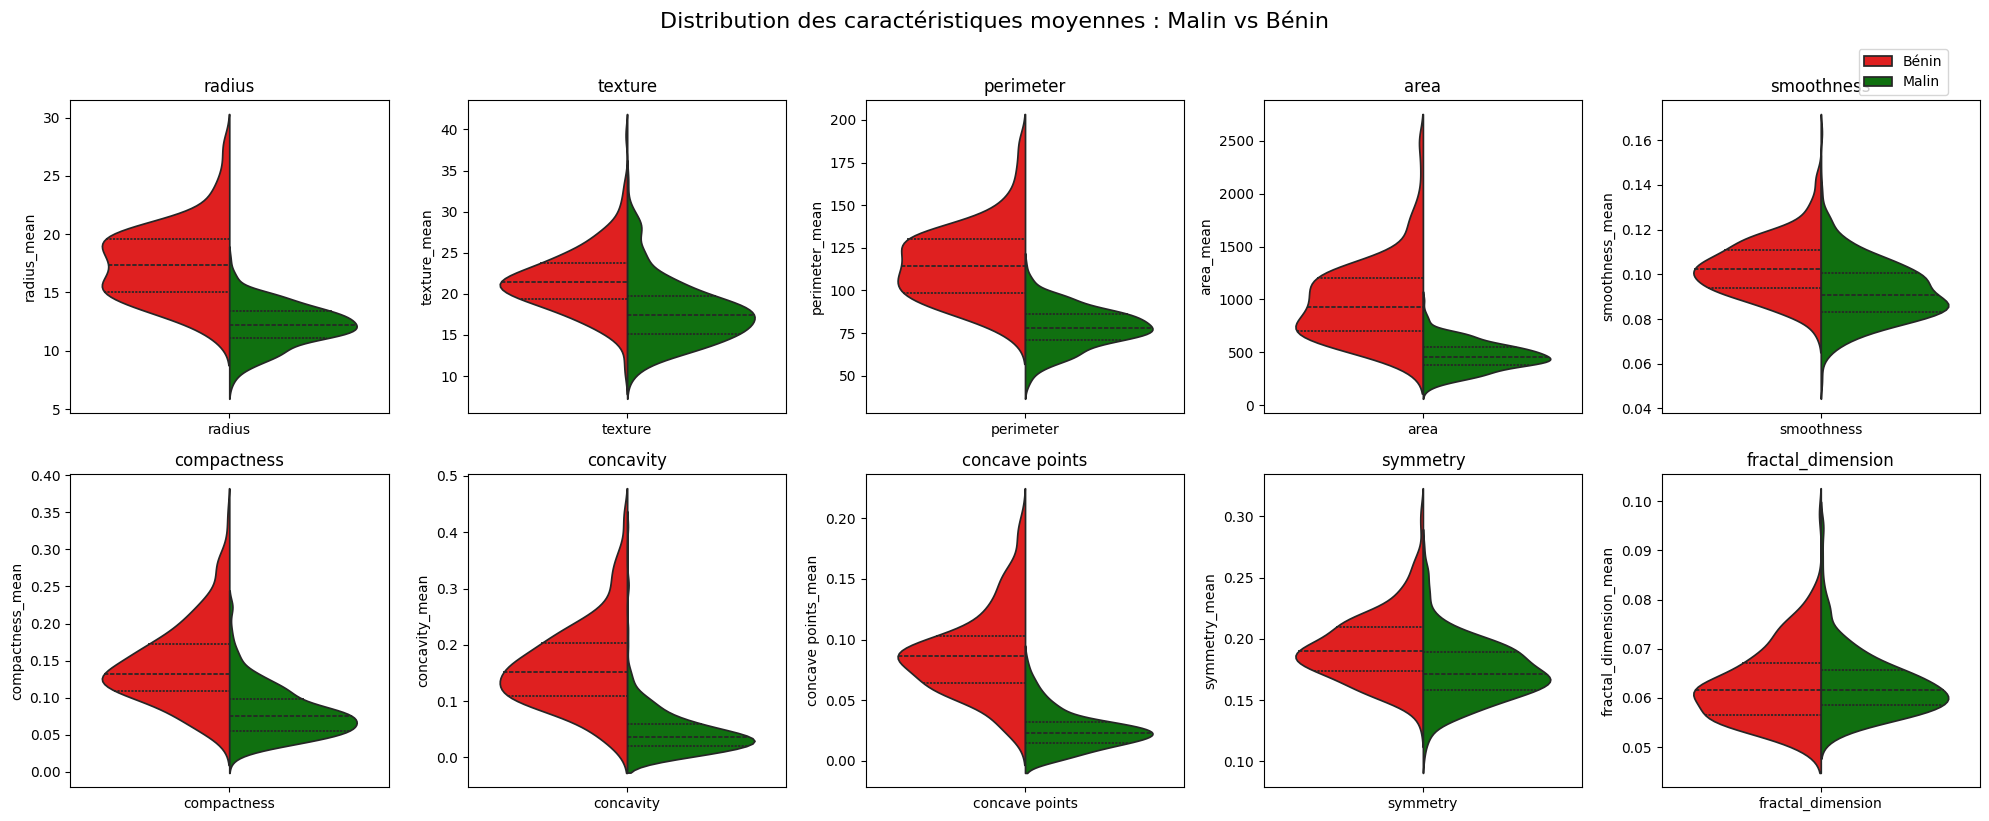

In [ ]:
### Graphique M vs B Mean ###
mean_features = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", 
                 "smoothness_mean", "compactness_mean", "concavity_mean", 
                 "concave points_mean", "symmetry_mean", "fractal_dimension_mean"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    # Créer une variable temporaire pour chaque feature
    data_temp = data.copy()
    data_temp['var'] = feature.replace('_mean', '')
    
    sns.violinplot(data=data_temp, x="var", y=feature, 
                   hue="diagnosis", split=True, inner="quart",
                   palette={'M': 'red', 'B': 'green'}, ax=axes[i])
    axes[i].set_title(f'{feature.replace("_mean", "")}')
    axes[i].set_xlabel('')
    axes[i].legend().remove()  # Enlever la légende de chaque subplot

# Ajouter une légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Bénin', 'Malin'], loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Distribution des caractéristiques moyennes : Malin vs Bénin', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

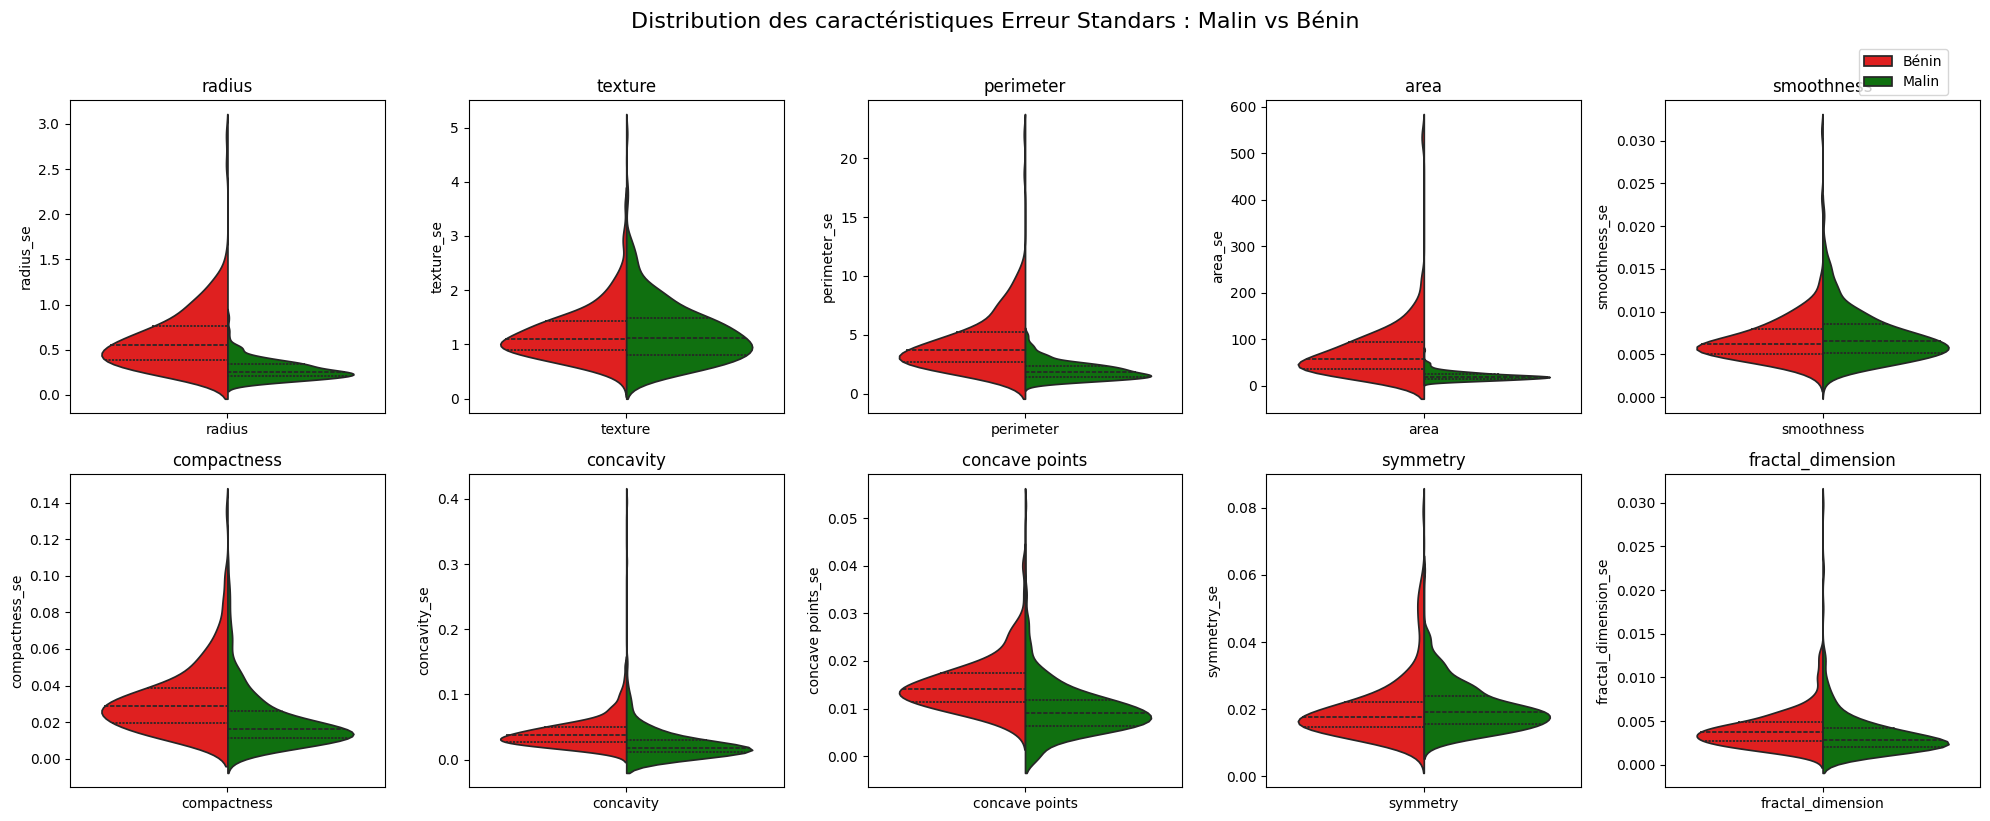

In [ ]:
### Graphique M vs B SE ###
mean_features = ["radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se",
                 "concavity_se","concave points_se","symmetry_se","fractal_dimension_se"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    # Créer une variable temporaire pour chaque feature
    data_temp = data.copy()
    data_temp['var'] = feature.replace('_se', '')
    
    sns.violinplot(data=data_temp, x="var", y=feature, 
                   hue="diagnosis", split=True, inner="quart",
                   palette={'M': 'red', 'B': 'green'}, ax=axes[i])
    axes[i].set_title(f'{feature.replace("_se", "")}')
    axes[i].set_xlabel('')
    axes[i].legend().remove()  # Enlever la légende de chaque subplot

# Ajouter une légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Bénin', 'Malin'], loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Distribution des caractéristiques Erreur Standars : Malin vs Bénin', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

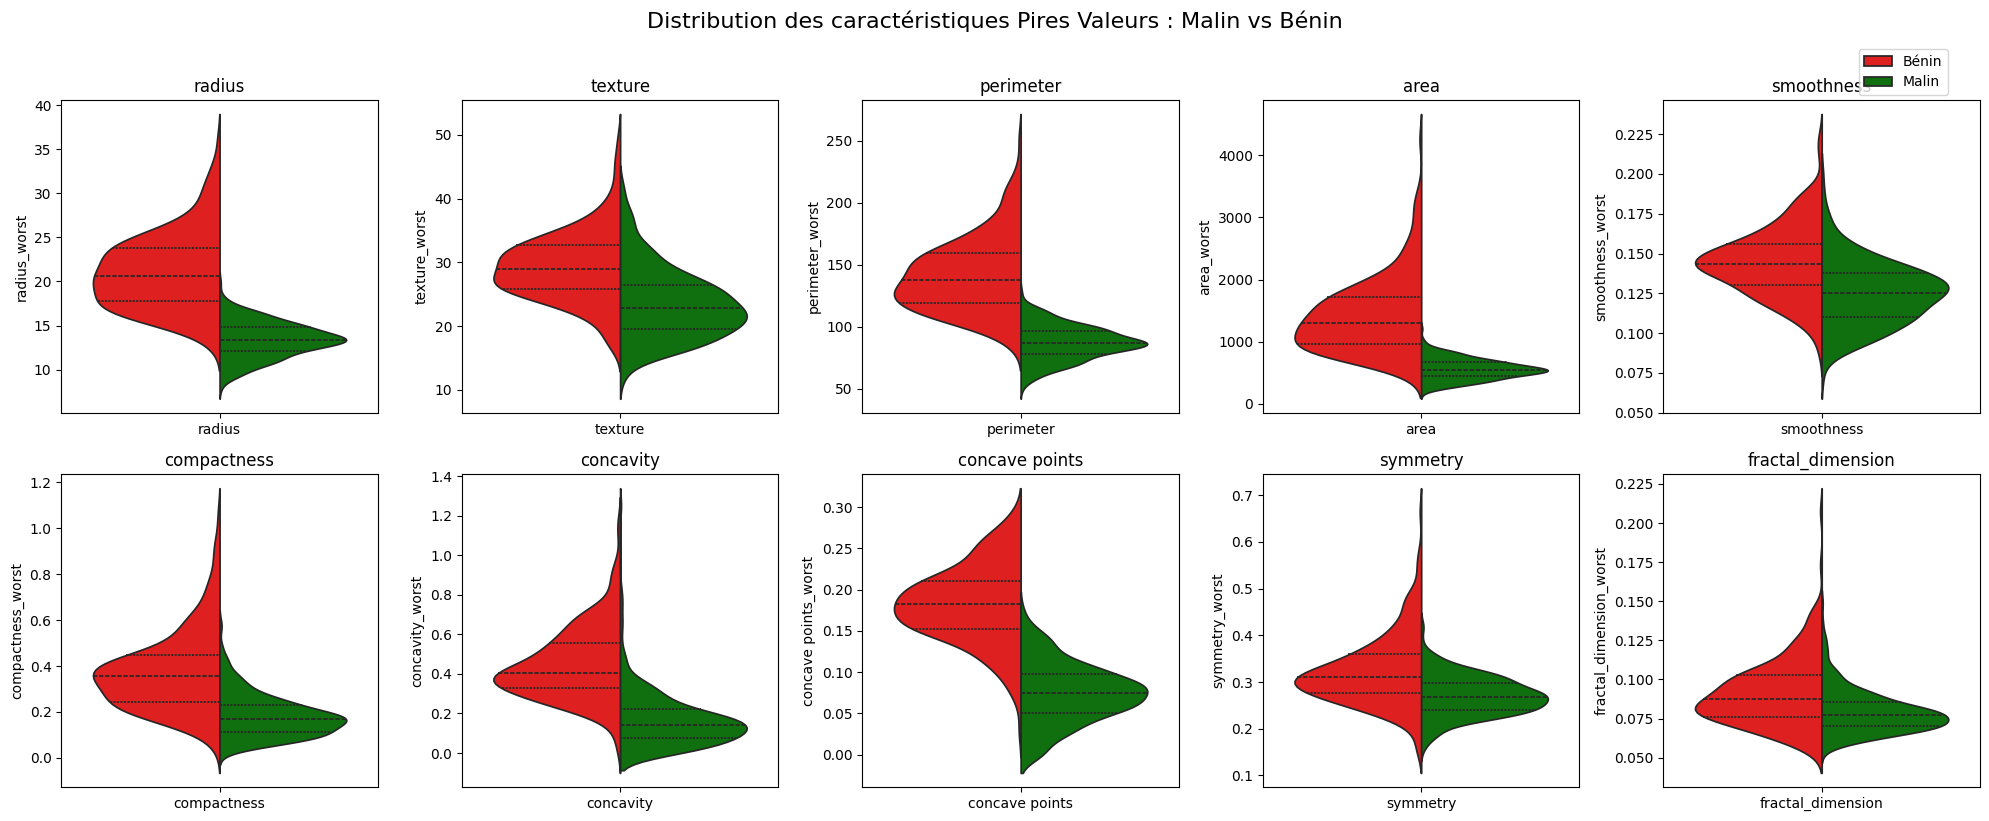

In [ ]:
### Graphique M vs B Worst ###
mean_features = ["radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
                 "compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    # Créer une variable temporaire pour chaque feature
    data_temp = data.copy()
    data_temp['var'] = feature.replace('_worst', '')
    
    sns.violinplot(data=data_temp, x="var", y=feature, 
                   hue="diagnosis", split=True, inner="quart",
                   palette={'M': 'red', 'B': 'green'}, ax=axes[i])
    axes[i].set_title(f'{feature.replace("_worst", "")}')
    axes[i].set_xlabel('')
    axes[i].legend().remove()  # Enlever la légende de chaque subplot

# Ajouter une légende globale
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Bénin', 'Malin'], loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Distribution des caractéristiques Pires Valeurs : Malin vs Bénin', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

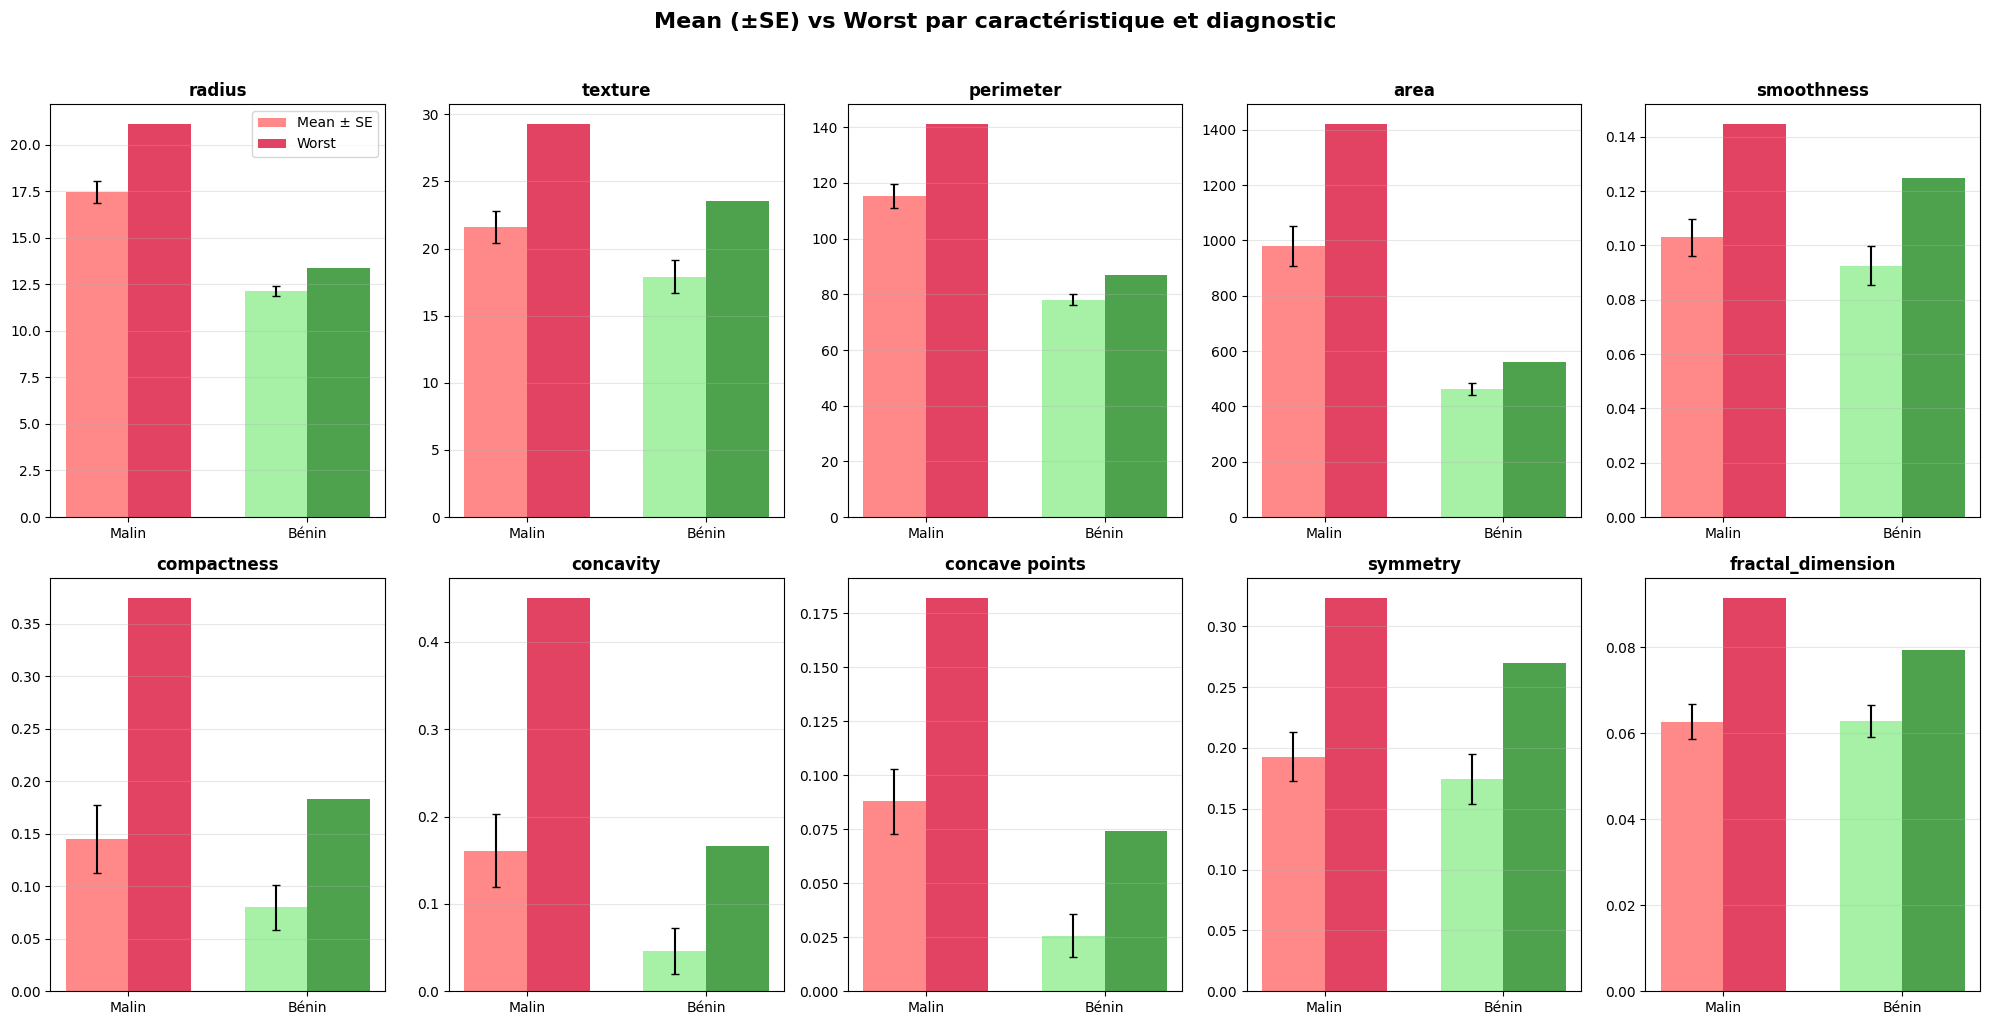

In [34]:
# ===== HISTOGRAMME GROUPÉ PAR CARACTÉRISTIQUE =====
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(base_features):
    ax = axes[i]
    
    # Données pour cette caractéristique
    mean_col = f"{feature}_mean"
    worst_col = f"{feature}_worst" 
    se_col = f"{feature}_se"
    
    # Calculer moyennes par diagnostic
    data_M = data[data['diagnosis'] == 'M']
    data_B = data[data['diagnosis'] == 'B']
    
    means = [data_M[mean_col].mean(), data_B[mean_col].mean()]
    worsts = [data_M[worst_col].mean(), data_B[worst_col].mean()]
    ses = [data_M[se_col].mean(), data_B[se_col].mean()]
    
    # Positions et largeurs
    x_pos = [0, 1]
    width = 0.35
    
    # Barres Mean avec erreur standard
    ax.bar([x - width/2 for x in x_pos], means, width, 
           color=[colors_mean['M'], colors_mean['B']], alpha=0.8,
           yerr=ses, error_kw=dict(ecolor='black', capsize=3),
           label='Mean ± SE')
    
    # Barres Worst
    ax.bar([x + width/2 for x in x_pos], worsts, width,
           color=[colors_worst['M'], colors_worst['B']], alpha=0.8,
           label='Worst')
    
    # Personnalisation
    ax.set_title(f'{feature}', fontsize=12, weight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Malin', 'Bénin'])
    ax.grid(True, alpha=0.3, axis='y')
    
    if i == 0:  # Légende seulement sur le premier
        ax.legend()

plt.suptitle('Mean (±SE) vs Worst par caractéristique et diagnostic', 
             fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

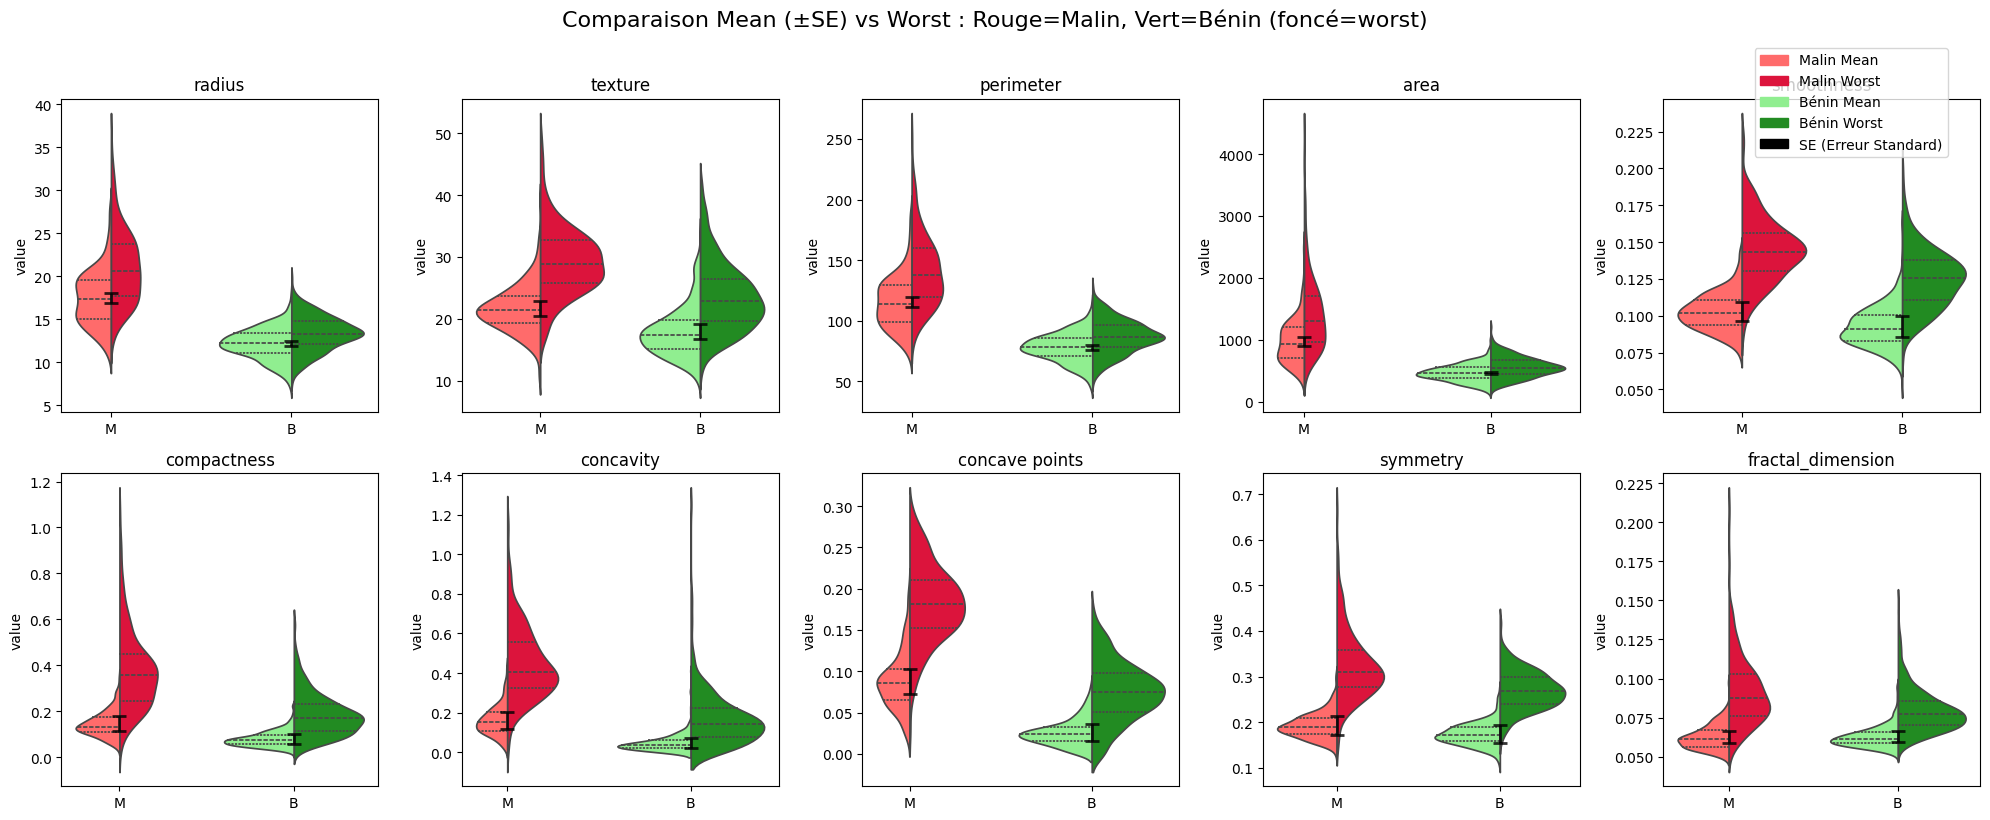

In [38]:
# ===== RESTRUCTURATION DES DONNÉES AVEC SE =====
comparison_data = []
base_features = ["radius", "texture", "perimeter", "area", "smoothness", 
                 "compactness", "concavity", "concave points", "symmetry", "fractal_dimension"]

for feature_base in base_features:
    mean_col = f"{feature_base}_mean"
    worst_col = f"{feature_base}_worst"
    se_col = f"{feature_base}_se"  # AJOUT DE L'ERREUR STANDARD
    
    for idx, row in data.iterrows():
        # Ajouter les données _mean
        comparison_data.append({
            'feature': feature_base,
            'value': row[mean_col],
            'se': row[se_col],  # STOCKER L'ERREUR STANDARD
            'type': 'mean',
            'diagnosis': row['diagnosis']
        })
        # Ajouter les données _worst
        comparison_data.append({
            'feature': feature_base,
            'value': row[worst_col],
            'se': 0,  # Pas d'erreur pour worst
            'type': 'worst',
            'diagnosis': row['diagnosis']
        })

comparison_df = pd.DataFrame(comparison_data)

# ===== CRÉATION DES VISUALISATIONS AVEC COULEURS MÉDICALES =====
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Définir la palette de couleurs médicales avec nuances
medical_palette = {
    'mean': '#FF6B6B',    # Rouge clair pour mean
    'worst': '#DC143C'    # Rouge foncé pour worst
}

for i, feature_base in enumerate(base_features):
    feature_data = comparison_df[comparison_df['feature'] == feature_base]
    
    # Créer le violinplot avec split par diagnostic ET type
    sns.violinplot(data=feature_data, 
                   x="diagnosis",              # M et B sur l'axe X
                   y="value", 
                   hue="type",                 # mean vs worst
                   split=True,                 # Diviser les violins
                   inner="quart", 
                   palette=medical_palette,    # Palette rouge clair/foncé
                   ax=axes[i])
    
    # ===== AJOUTER LES BARRES D'ERREUR SE SUR LES MEAN =====
    # Calculer les moyennes et SE pour chaque diagnostic (seulement pour mean)
    mean_data_M = feature_data[(feature_data['diagnosis'] == 'M') & (feature_data['type'] == 'mean')]
    mean_data_B = feature_data[(feature_data['diagnosis'] == 'B') & (feature_data['type'] == 'mean')]
    
    # Position des barres d'erreur (centrées sur les violins mean)
    x_positions = [0, 1]  # M=0, B=1
    
    # Moyennes et erreurs standard pour chaque diagnostic
    means = [mean_data_M['value'].mean(), mean_data_B['value'].mean()]
    ses = [mean_data_M['se'].mean(), mean_data_B['se'].mean()]
    
    # Ajouter les barres d'erreur
    axes[i].errorbar(x_positions, means, yerr=ses,
                     fmt='none',  # Pas de marqueur
                     ecolor='black',  # Couleur des barres d'erreur
                     elinewidth=2,    # Épaisseur des lignes
                     capsize=5,       # Taille des barres horizontales
                     capthick=2,      # Épaisseur des barres horizontales
                     alpha=0.8)       # Transparence
    
    # Personnalisation
    axes[i].set_title(f'{feature_base}')
    axes[i].set_xlabel('')
    axes[i].legend().remove()

# ===== POST-TRAITEMENT POUR COULEURS SPÉCIFIQUES =====
# Couleurs spécifiques : Rouge pour M, Vert pour B
colors_M = ['#FF6B6B', '#DC143C']  # Rouge clair, Rouge foncé pour Malin
colors_B = ['#90EE90', '#228B22']  # Vert clair, Vert foncé pour Bénin

for ax in axes:
    # Parcourir tous les violins dans le subplot
    for i, collection in enumerate(ax.collections):
        if isinstance(collection, PolyCollection):
            # Alternance des couleurs : M mean, M worst, B mean, B worst
            if i == 0:      # M mean
                collection.set_facecolor(colors_M[0])
            elif i == 1:    # M worst  
                collection.set_facecolor(colors_M[1])
            elif i == 2:    # B mean
                collection.set_facecolor(colors_B[0])
            elif i == 3:    # B worst
                collection.set_facecolor(colors_B[1])

# ===== LÉGENDE PERSONNALISÉE =====
# Créer des patches pour la légende
legend_elements = [
    mpatches.Patch(color=colors_M[0], label='Malin Mean'),
    mpatches.Patch(color=colors_M[1], label='Malin Worst'),
    mpatches.Patch(color=colors_B[0], label='Bénin Mean'),
    mpatches.Patch(color=colors_B[1], label='Bénin Worst'),
    mpatches.Patch(color='black', label='SE (Erreur Standard)')  # AJOUT SE
]

fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Comparaison Mean (±SE) vs Worst : Rouge=Malin, Vert=Bénin (foncé=worst)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

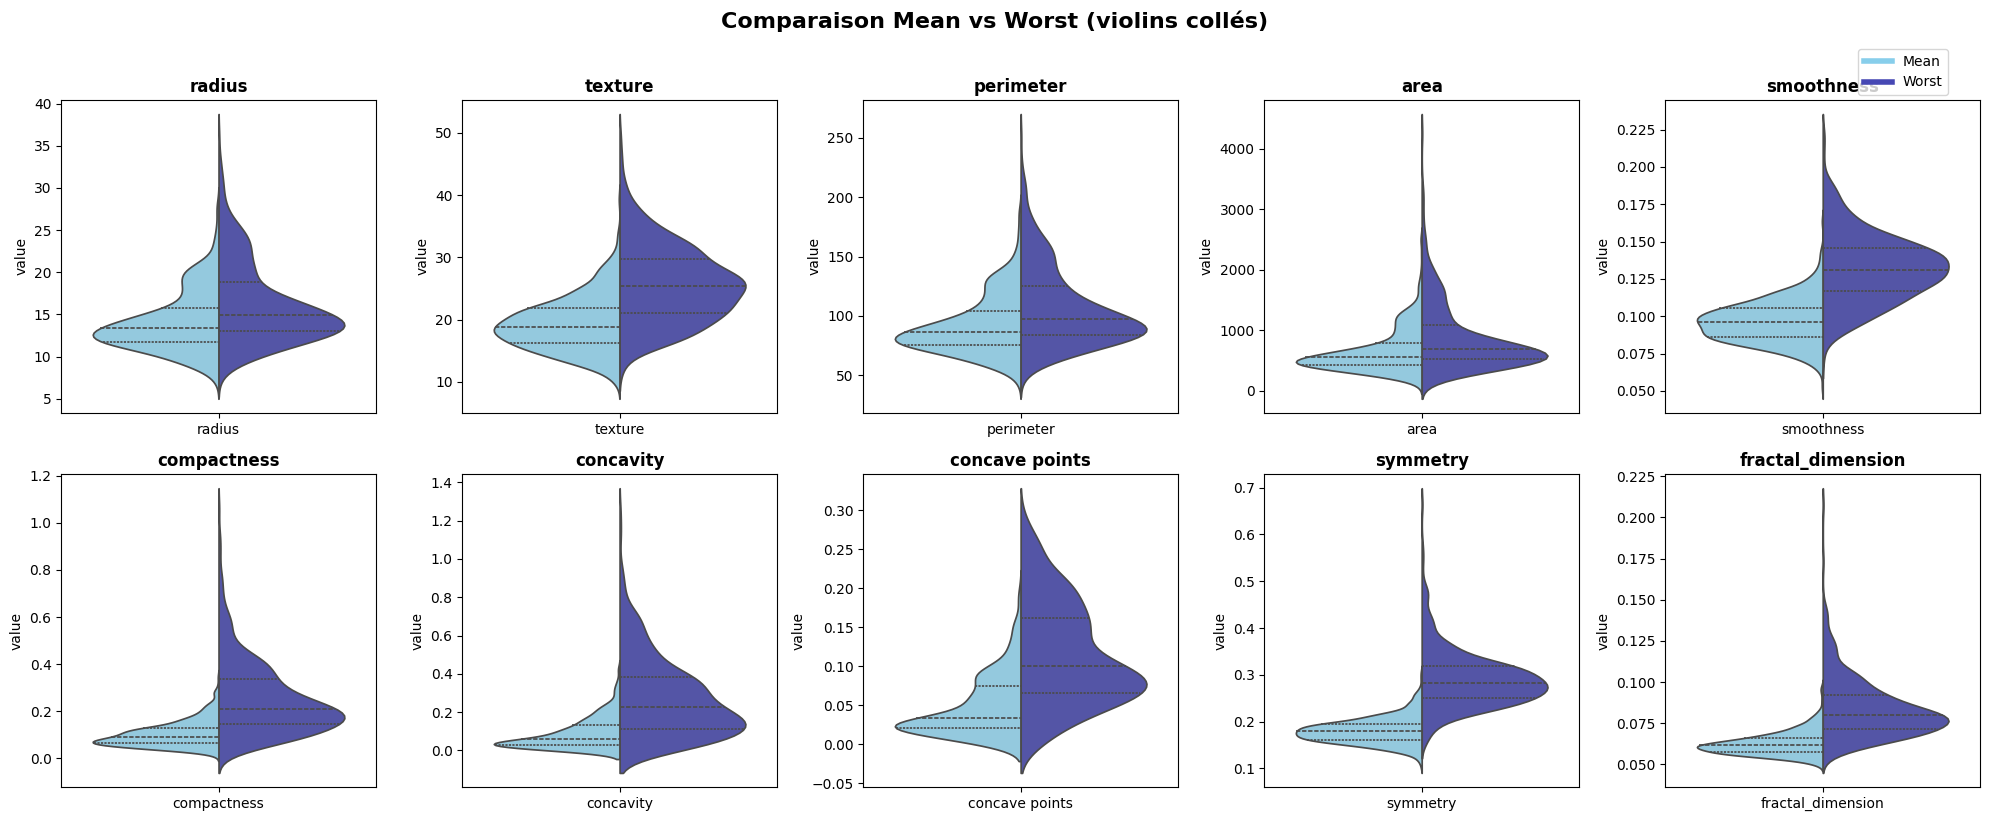

In [ ]:
# ===== RESTRUCTURATION SIMPLE MEAN VS WORST =====
comparison_data = []
base_features = ["radius", "texture", "perimeter", "area", "smoothness", 
                 "compactness", "concavity", "concave points", "symmetry", "fractal_dimension"]

for feature_base in base_features:
    mean_col = f"{feature_base}_mean"
    worst_col = f"{feature_base}_worst"
    
    # Ajouter toutes les données sans distinction diagnostic
    for idx, row in data.iterrows():
        # Données _mean
        comparison_data.append({
            'feature': feature_base,
            'value': row[mean_col],
            'type': 'mean'
        })
        # Données _worst
        comparison_data.append({
            'feature': feature_base,
            'value': row[worst_col],
            'type': 'worst'
        })

comparison_df = pd.DataFrame(comparison_data)

# ===== DÉFINIR LA PALETTE DE COULEURS =====
simple_palette = {
    'mean': '#87CEEB',    # Bleu clair pour mean
    'worst': "#4648B4"    # Bleu foncé pour worst
}

# ===== VERSION AVEC VIOLINS COLLÉS =====
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature_base in enumerate(base_features):
    feature_data = comparison_df[comparison_df['feature'] == feature_base]
    
    # Créer une variable temporaire pour avoir split
    feature_data_temp = feature_data.copy()
    feature_data_temp['var'] = feature_base
    
    # Violinplot avec split
    sns.violinplot(data=feature_data_temp, 
                   x="var",                 # Feature name sur X
                   y="value", 
                   hue="type",              # mean vs worst
                   split=True,              # Violins collés
                   inner="quart",
                   palette=simple_palette,  # MAINTENANT DÉFINI
                   ax=axes[i])
    
    # Personnalisation
    axes[i].set_title(f'{feature_base}', fontsize=12, weight='bold')
    axes[i].set_xlabel('')
    axes[i].legend().remove()

# Légende globale
legend_elements = [
    plt.Line2D([0], [0], color=simple_palette['mean'], lw=4, label='Mean'),
    plt.Line2D([0], [0], color=simple_palette['worst'], lw=4, label='Worst')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Comparaison Mean vs Worst', 
             fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

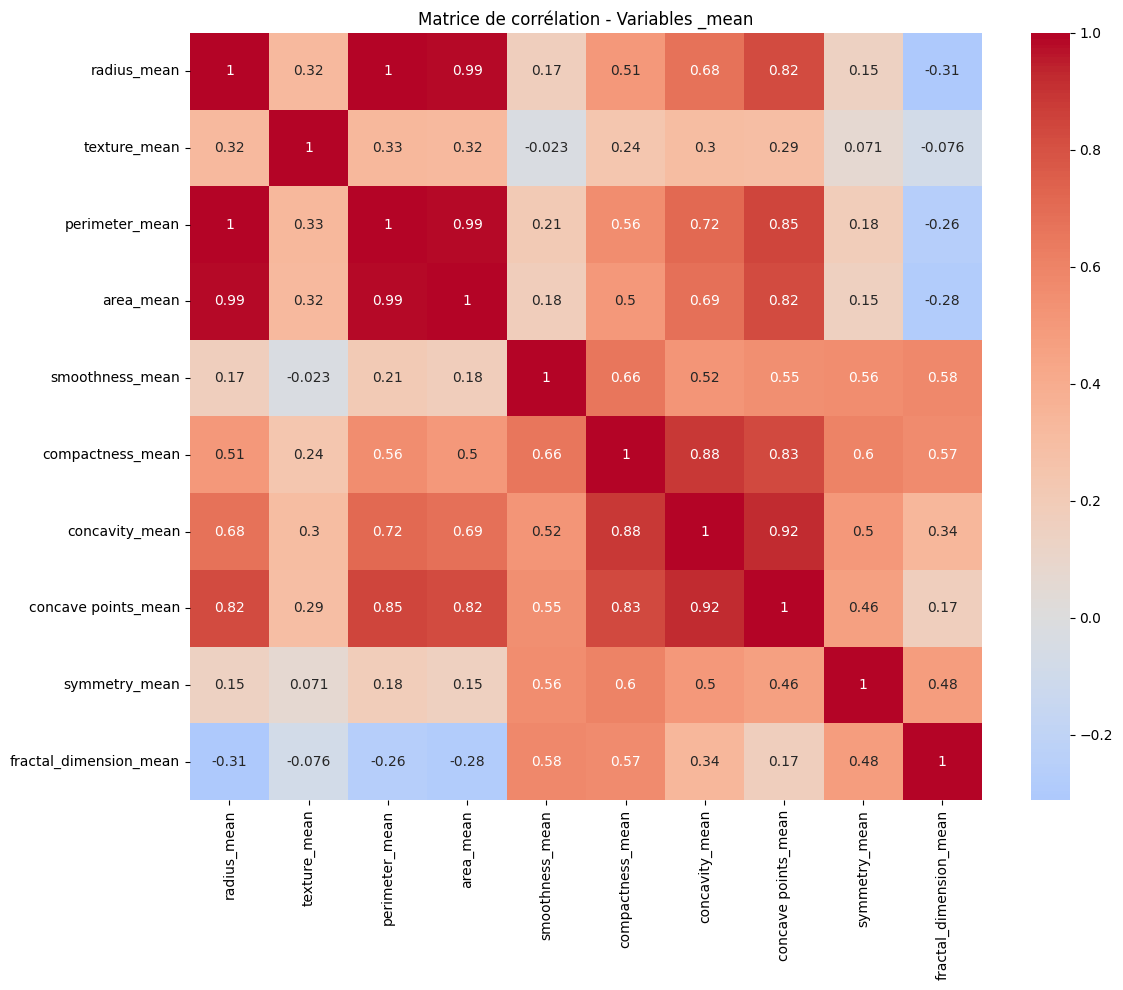

In [42]:
# Matrice de corrélation des variables _mean
mean_cols = [col for col in data.columns if '_mean' in col]
plt.figure(figsize=(12, 10))
correlation_matrix = data[mean_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation - Variables _mean')
plt.tight_layout()
plt.show()

La dernière colonne vide a été supprimée.


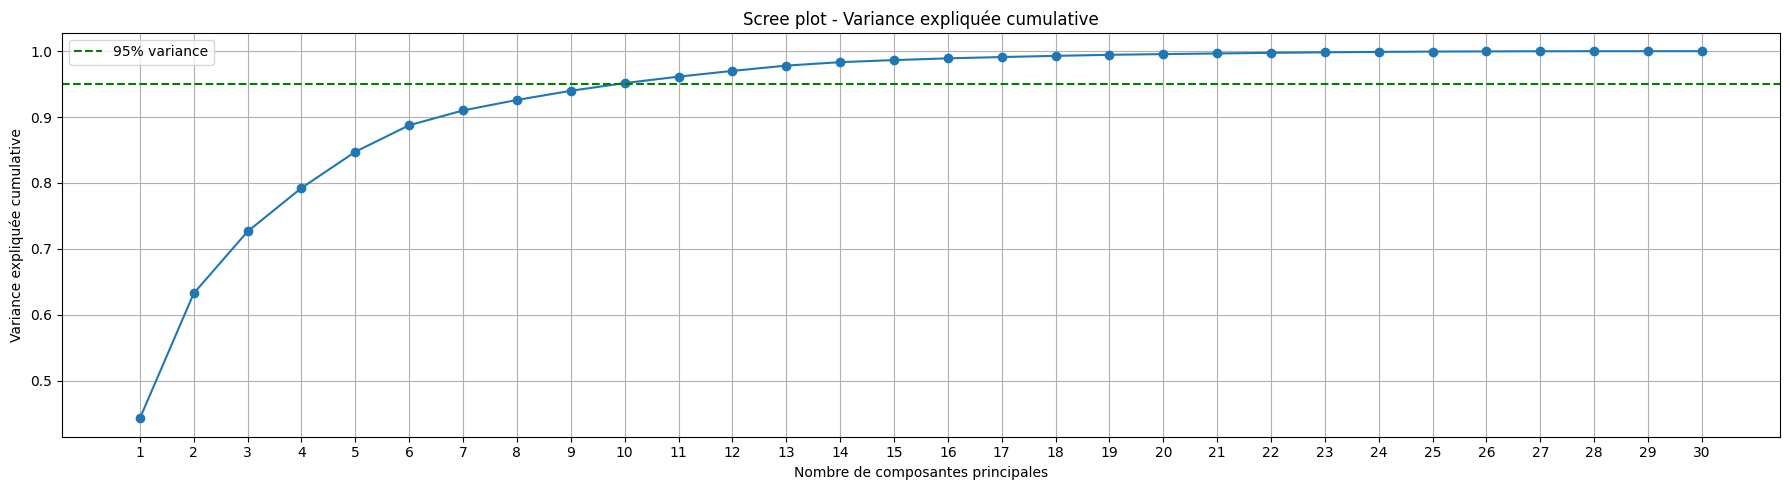

Nombre de PC pour 95% de variance expliquée : 10


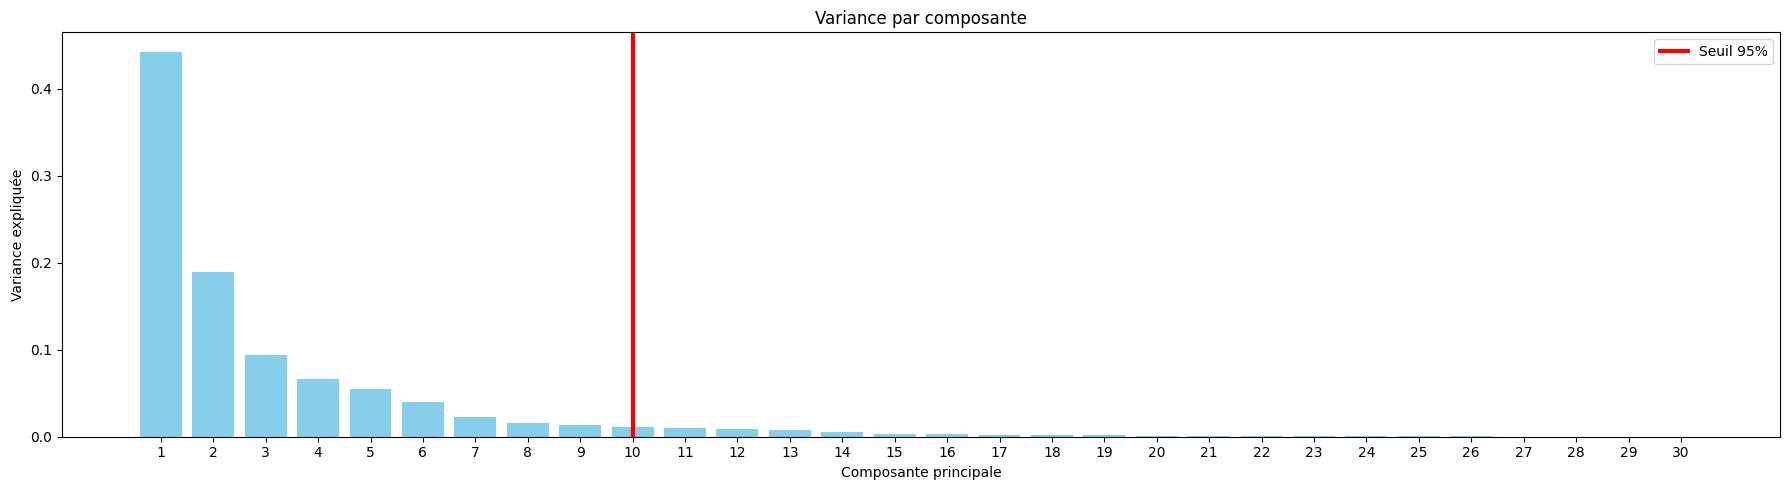

Tableau 'loadings' sauvegardé en tant que 'loadings_pca_table.png'.


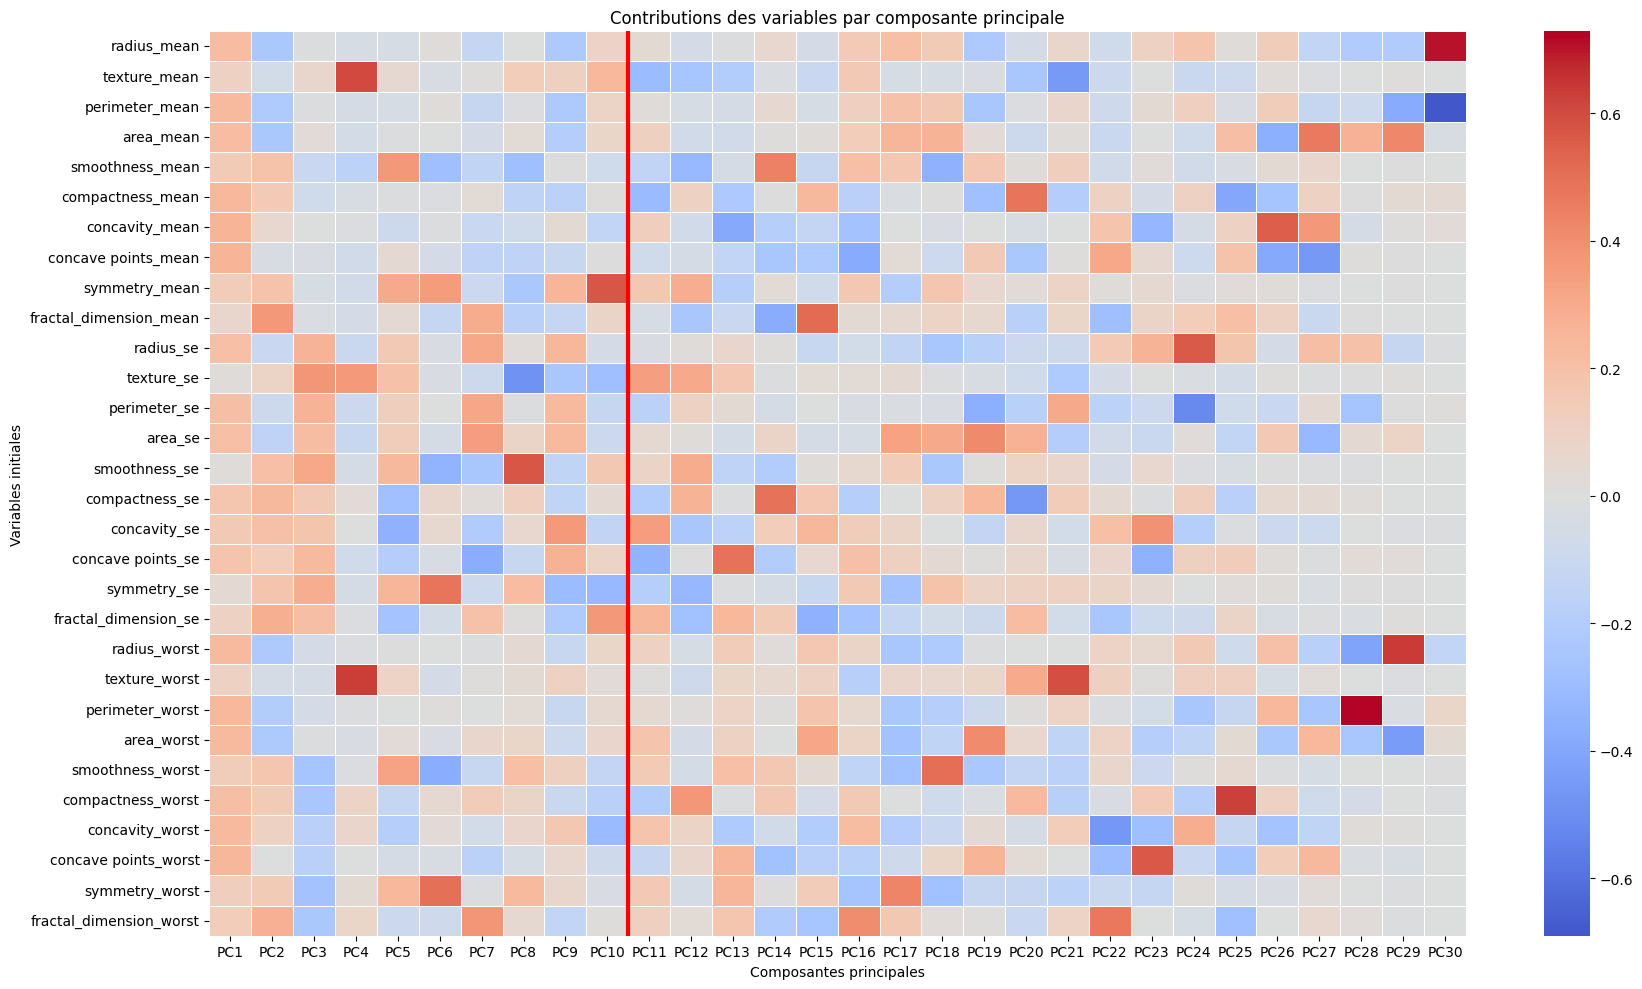

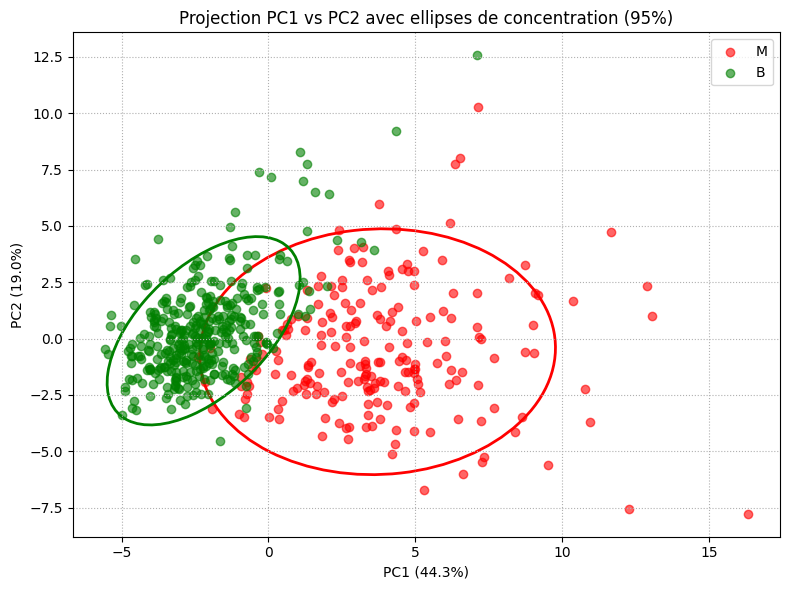


=== Top variables par composante ===
PC1 : concave points_mean, concavity_mean, concave points_worst
PC2 : fractal_dimension_mean, fractal_dimension_se, fractal_dimension_worst
PC3 : texture_se, smoothness_se, symmetry_se
PC4 : texture_worst, texture_mean, texture_se
PC5 : smoothness_mean, concavity_se, smoothness_worst
PC6 : symmetry_worst, symmetry_se, smoothness_worst
PC7 : fractal_dimension_worst, concave points_se, area_se
PC8 : smoothness_se, texture_se, smoothness_mean
PC9 : concavity_se, symmetry_se, concave points_se
PC10 : symmetry_mean, fractal_dimension_se, symmetry_se
PC11 : concavity_se, texture_se, concave points_se
PC12 : compactness_worst, symmetry_se, smoothness_mean
PC13 : concave points_se, concavity_mean, symmetry_worst
PC14 : compactness_se, smoothness_mean, fractal_dimension_mean
PC15 : fractal_dimension_mean, fractal_dimension_se, area_worst
PC16 : fractal_dimension_worst, concave points_mean, concavity_mean
PC17 : symmetry_worst, area_se, smoothness_worst
PC18

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse

# Fonction ellipse élargie
def draw_ellipse(position, covariance, ax=None, n_std=2, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * n_std * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * n_std * np.sqrt(covariance)
    ellipse = Ellipse(xy=position, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Chargement des données
file_path = Path("Data") / "bcw_data.csv"
data = pd.read_csv(file_path)
if data.iloc[:, -1].isnull().all():
    data = data.iloc[:, :-1]
    print("La dernière colonne vide a été supprimée.")

features = data.drop(['id', 'diagnosis'], axis=1)
target = data['diagnosis']
features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median())
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA()
pca.fit(features_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
nb_comp = len(explained_var)
idx_95 = np.argmax(cumulative_var >= 0.95) + 1

# Scree plot
plt.figure(figsize=(max(12, nb_comp*0.6), 5))
plt.plot(range(1, nb_comp+1), cumulative_var, marker='o')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulative')
plt.title('Scree plot - Variance expliquée cumulative')
plt.xticks(range(1, nb_comp+1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Nombre de PC pour 95% de variance expliquée : {idx_95}")

# Variance par composante avec ligne 95%
plt.figure(figsize=(max(12, nb_comp*0.6), 5))
plt.bar(range(1, nb_comp+1), explained_var, color='skyblue')
plt.axvline(x=idx_95, color='red', linewidth=3, label='Seuil 95%')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Variance par composante')
plt.xticks(range(1, nb_comp+1))
plt.legend()
plt.tight_layout()
plt.show()

# Calcul des loadings
loadings = pd.DataFrame(pca.components_.T, index=features.columns,
                        columns=[f'PC{i+1}' for i in range(nb_comp)])

# Sauvegarder le tableau loadings en image PNG
fig, ax = plt.subplots(figsize=(min(20, 0.5*loadings.shape[1]), min(20, 0.5*loadings.shape[0])))
ax.axis('off')
table = ax.table(cellText=loadings.round(3).values, rowLabels=loadings.index, colLabels=loadings.columns,
                 cellLoc='center', rowLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
plt.tight_layout()
plt.savefig('Graphique/loadings_pca_table.png', dpi=300, bbox_inches='tight')
plt.close(fig)
print("Tableau 'loadings' sauvegardé en tant que 'loadings_pca_table.png'.")

# Heatmap des loadings + ligne 95%
plt.figure(figsize=(max(12, nb_comp*0.6), 10))
sns.heatmap(loadings, cmap='coolwarm', center=0, linewidths=0.5)
plt.axvline(x=idx_95, color='red', linewidth=3)
plt.title('Contributions des variables par composante principale')
plt.xlabel('Composantes principales')
plt.ylabel('Variables initiales')
plt.tight_layout()
plt.show()

# Projection 2D avec ellipses (n_std=2)
if nb_comp >= 2:
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    colors = target.map({'M': 'red', 'B': 'green'})
    pcs = pca.transform(features_scaled)[:, :2]
    for label, color in zip(['M', 'B'], ['red', 'green']):
        points = pcs[target == label]
        plt.scatter(points[:, 0], points[:, 1], c=color, alpha=0.6, label=label)
        mean = points.mean(axis=0)
        cov = np.cov(points, rowvar=False)
        draw_ellipse(mean, cov, ax=ax, n_std=2, edgecolor=color, facecolor='none', linewidth=2)
    plt.xlabel(f'PC1 ({explained_var[0]:.1%})')
    plt.ylabel(f'PC2 ({explained_var[1]:.1%})')
    plt.title("Projection PC1 vs PC2 avec ellipses de concentration (95%)")
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    plt.show()

# Top features par composante
print("\n=== Top variables par composante ===")
for i in range(nb_comp):
    sorted_vars = loadings.iloc[:, i].abs().sort_values(ascending=False)
    print(f"PC{i+1} : {', '.join(sorted_vars.index[:3])}")

# Dataframe PCA pour suite
df_pca = pd.DataFrame(pca.transform(features_scaled),
                      columns=[f'PC{i+1}' for i in range(nb_comp)])
df_pca['diagnosis'] = target.values

print("\n=== Données PCA transformées ===")
print(df_pca.shape)
print(df_pca.head())


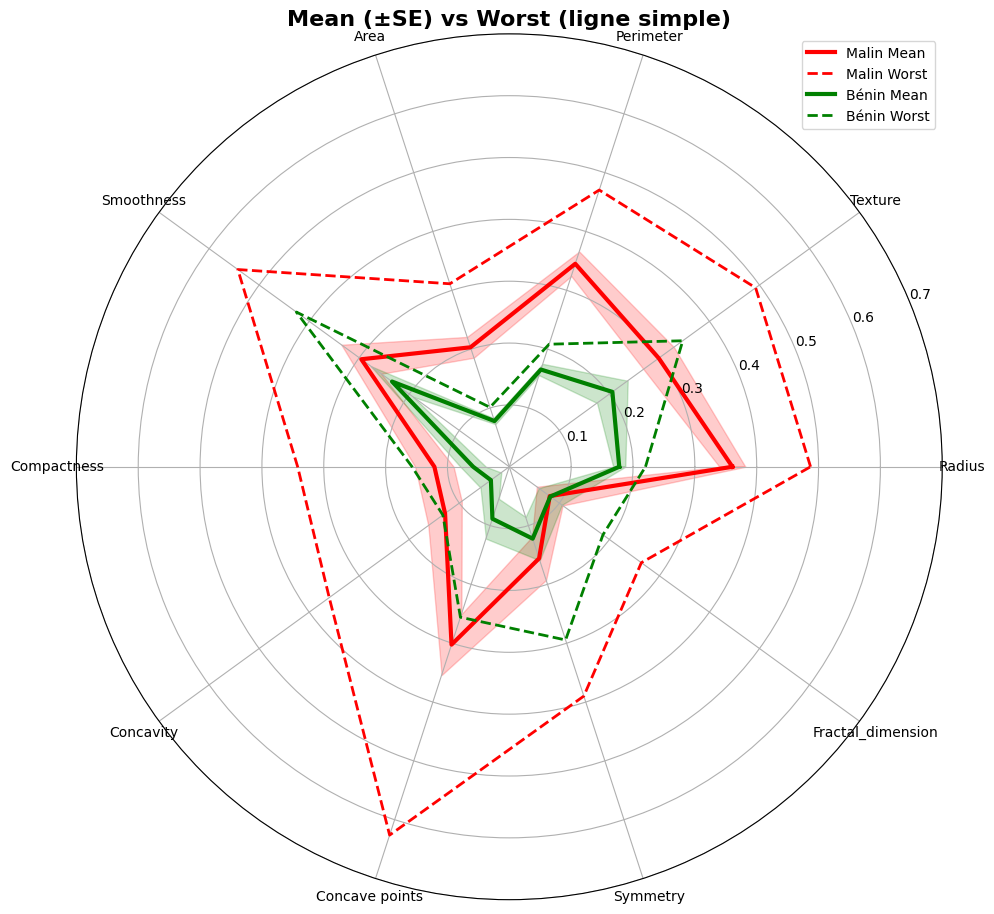

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# ------ Liste des features principales à analyser ------
features_base = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave points', 'symmetry', 'fractal_dimension']

# Préparer un dictionnaire pour stocker les données du radar chart
data_radar = {}

# Boucle sur chaque type de tumeur : M (malin), B (bénin)
for diagnosis in ['M', 'B']:
    subset = data[data['diagnosis'] == diagnosis]  # Extraction des données du type voulu
    
    means = []     # Pour stocker les moyennes normalisées
    ses = []       # Pour stocker les erreurs standard normalisées
    worsts = []    # Pour stocker les valeurs "worst" normalisées
    
    # Boucle sur chaque feature de base
    for feature in features_base:
        mean_col = f"{feature}_mean"
        se_col = f"{feature}_se"
        worst_col = f"{feature}_worst"
        
        # Moyennes sur cette sous-population
        mean_val = subset[mean_col].mean()
        se_val = subset[se_col].mean()
        worst_val = subset[worst_col].mean()
        
        # === CORRECTION IMPORTANTE ===
        # Utilisation d'une échelle commune (min/max sur mean ET worst)
        all_values = pd.concat([data[mean_col], data[worst_col]])
        global_min = all_values.min()
        global_max = all_values.max()
        
        norm_mean = (mean_val - global_min) / (global_max - global_min)
        norm_worst = (worst_val - global_min) / (global_max - global_min)
        # Pour SE, toujours le ramener à l'échelle commune
        norm_se = se_val / (global_max - global_min)
        
        means.append(norm_mean)
        ses.append(norm_se)
        worsts.append(norm_worst)
    
    # Ajout de la première valeur à la fin de chaque liste pour "fermer" le radar (boucler le polygone)
    data_radar[diagnosis] = {
        'means': means + [means[0]],
        'ses': ses + [ses[0]],
        'worsts': worsts + [worsts[0]]
    }

# ------ Calcul des angles pour chaque axe du graphique radar ------
N = len(features_base)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # On referme la boucle

# ------ Création de la figure radar ------
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Dictionnaires pour la couleur et les labels des groupes
colors = {'M': 'red', 'B': 'green'}
labels = {'M': 'Malin', 'B': 'Bénin'}

# Boucle sur chaque diagnostic pour tracer les données sur le radar
for diagnosis in ['M', 'B']:
    means = data_radar[diagnosis]['means']
    ses = data_radar[diagnosis]['ses']
    worsts = data_radar[diagnosis]['worsts']
    
    # Tracé de la "mean" (trait principal, plein)
    ax.plot(angles, means, color=colors[diagnosis], linewidth=3,
            label=f'{labels[diagnosis]} Mean', linestyle='-')
    
    # Tracé de la zone ± SE (autour du trait mean, colorée et semi-transparente)
    upper = [m + s for m, s in zip(means, ses)]
    lower = [max(0, m - s) for m, s in zip(means, ses)]  # On évite de descendre sous zéro
    ax.fill_between(angles, lower, upper, color=colors[diagnosis], alpha=0.2)
    
    # Tracé de la "worst" (trait pointillé, plus fin)
    ax.plot(angles, worsts, color=colors[diagnosis], linewidth=2,
            label=f'{labels[diagnosis]} Worst', linestyle='--')

# ------ Personnalisation de l’affichage ------
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.capitalize() for f in features_base])
ax.set_ylim(0, 0.7)
ax.set_title('Mean (±SE) vs Worst (ligne simple)', size=16, weight='bold')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


PCA 95% → 10 composantes


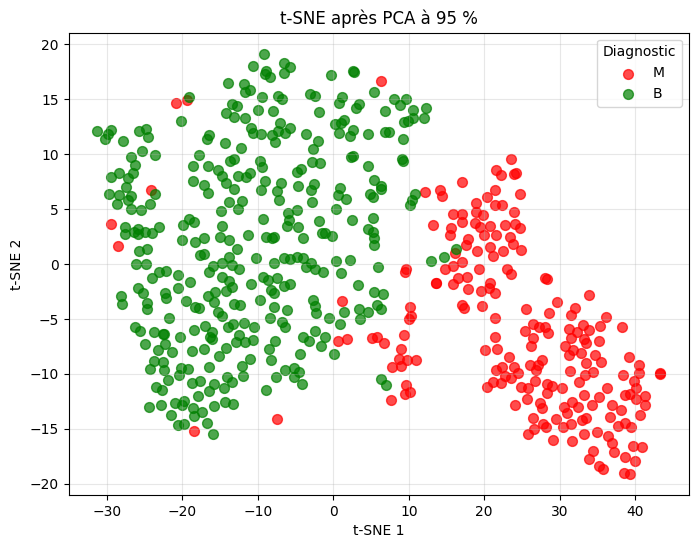

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Chargement et nettoyage
file_path = Path("Data") / "bcw_data.csv"
data = pd.read_csv(file_path)

# Supprimer colonnes vides et colonnes non numériques
data = data.loc[:, data.columns.notna()]
if data.iloc[:, -1].isnull().all():
    data = data.iloc[:, :-1]
features = data.drop(['id', 'diagnosis'], axis=1)
features = features.replace([np.inf, -np.inf], np.nan).fillna(features.median())

# 2. Standardisation
scaler = StandardScaler()  # Crée un standardiseur
X_scaled = scaler.fit_transform(features)  # Centre et réduit chaque variable

# 3. PCA à 95 % de variance
pca95 = PCA(n_components=0.95, random_state=42)  # Garde assez de PC pour expliquer 95% de la variance
X_pca95 = pca95.fit_transform(X_scaled)  # Applique la PCA
print(f"PCA 95% → {X_pca95.shape[1]} composantes")  # Affiche le nombre de PC retenues

# 4. t-SNE sur les composantes PCA
tsne = TSNE(
    n_components=2,         # Projection en 2D
    perplexity=30,          # Nombre de voisins pris en compte
    learning_rate='auto',   # Taux d'apprentissage automatique
    init='pca',             # Initialisation par PCA (plus stable)
    random_state=42,        # Pour reproductibilité
    max_iter=1000           # Nombre d'itérations d'optimisation
)
X_tsne = tsne.fit_transform(X_pca95)  # Applique t-SNE sur les données PCA

# 5. Visualisation t-SNE
target = data['diagnosis']  # Récupère la colonne cible
colors = {'M': 'red', 'B': 'green'}  # Couleurs pour chaque classe

plt.figure(figsize=(8, 6))  # Crée une figure de taille 8x6
for label in ['M', 'B']:
    mask = (target == label)  # Sélectionne les indices de la classe
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[label], label=label, alpha=0.7, s=50)  # Affiche les points
plt.title("t-SNE après PCA à 95 %")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Diagnostic")
plt.grid(True, alpha=0.3)
plt.show()


La dernière colonne vide a été supprimée.
Shape après suppression colonne vide et nettoyage : (569, 30)
PCA 95% → 10 composantes


c:\Users\romua\Documents\La Plateforme_\Projet 4 - Perceptron\Perceptron\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\romua\Documents\La Plateforme_\Projet 4 - Perceptron\Perceptron\.env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


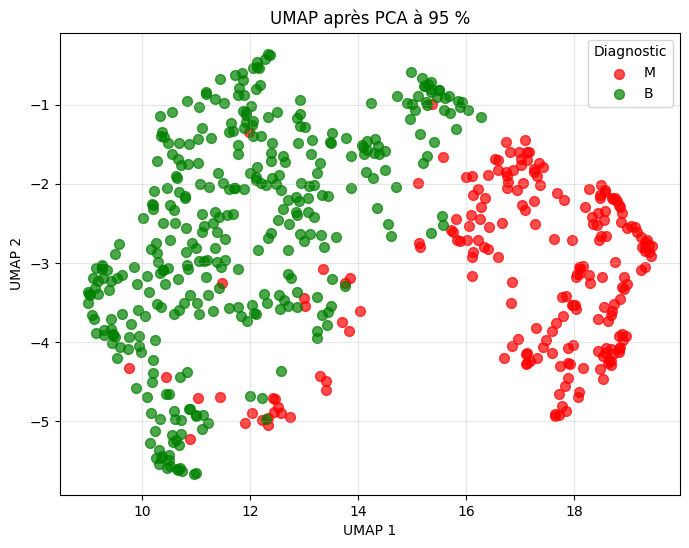

In [11]:
# === 1. Chargement et nettoyage des données ===
from pathlib import Path
import pandas as pd
import numpy as np

# Définir le chemin du fichier CSV
file_path = Path("Data") / "bcw_data.csv"

# Charger le fichier CSV dans un DataFrame pandas
data = pd.read_csv(file_path)

# Supprimer les colonnes dont le nom est NaN (sécurité)
data = data.loc[:, data.columns.notna()]

# Si la dernière colonne est entièrement vide, on la supprime
def last_col_is_empty(df):
    return df.iloc[:, -1].isnull().all()
if last_col_is_empty(data):
    data = data.iloc[:, :-1]
    print("La dernière colonne vide a été supprimée.")

# Sélectionner les variables explicatives (toutes sauf 'id' et 'diagnosis')
features = data.drop(['id', 'diagnosis'], axis=1)

# Remplacer les valeurs infinies par NaN, puis les NaN par la médiane de chaque colonne
features = features.replace([np.inf, -np.inf], np.nan).fillna(features.median())
print("Shape après suppression colonne vide et nettoyage :", features.shape)

# === 2. Standardisation des variables ===
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  # Crée un standardiseur
X_scaled = scaler.fit_transform(features)  # Centre et réduit chaque variable

# === 3. Réduction de dimension par PCA (95% de variance) ===
from sklearn.decomposition import PCA
pca95 = PCA(n_components=0.95, random_state=42)  # Garde assez de PC pour expliquer 95% de la variance
X_pca95 = pca95.fit_transform(X_scaled)  # Applique la PCA
print(f"PCA 95% → {X_pca95.shape[1]} composantes")  # Affiche le nombre de PC retenues

# === 4. UMAP sur les composantes PCA ===
import umap.umap_ as umap
umap_reducer = umap.UMAP(
    n_components=2,        # Projection en 2D
    n_neighbors=15,        # Nombre de voisins pour la structure locale
    min_dist=0.1,          # Distance minimale entre points projetés
    metric='euclidean',    # Métrique de distance
    random_state=42        # Pour reproductibilité
)
X_umap = umap_reducer.fit_transform(X_pca95)  # Applique UMAP sur les données PCA

# === 5. Visualisation UMAP colorée par diagnostic ===
import matplotlib.pyplot as plt

target = data['diagnosis']  # Récupère la colonne cible
colors = {'M': 'red', 'B': 'green'}  # Couleurs pour chaque classe

plt.figure(figsize=(8, 6))  # Crée une figure de taille 8x6
for label in ['M', 'B']:
    mask = (target == label)  # Sélectionne les indices de la classe
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                c=colors[label], label=label, alpha=0.7, s=50)  # Affiche les points
plt.title("UMAP après PCA à 95 %")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Diagnostic")
plt.grid(True, alpha=0.3)
plt.show()


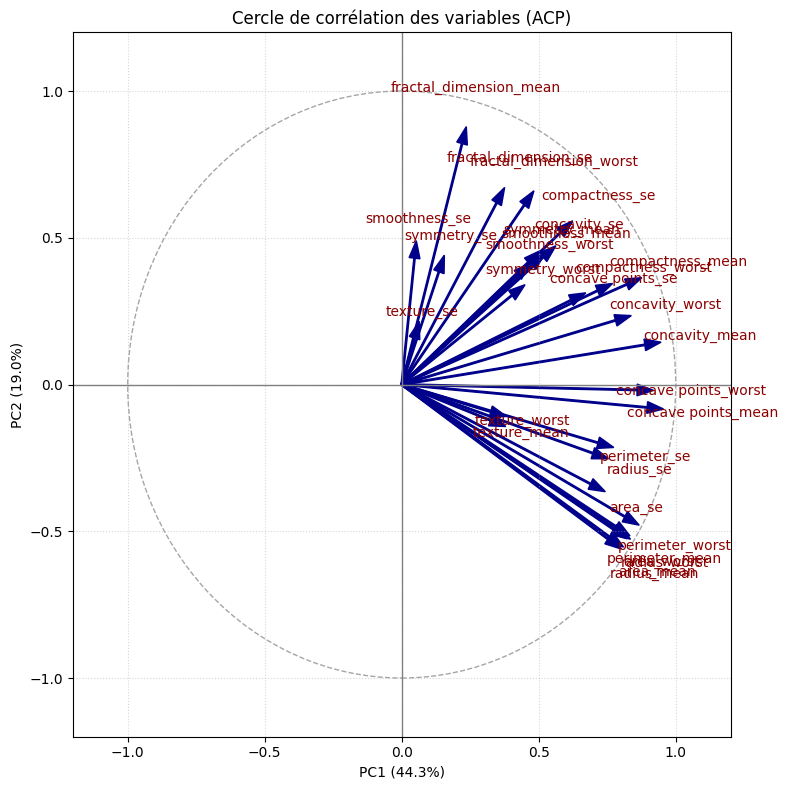

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path

# Chargement et préparation
df = pd.read_csv(Path("Data") / "bcw_data.csv")
df = df.loc[:, df.columns.notna()]
if df.iloc[:, -1].isnull().all():
    df = df.iloc[:, :-1]
X = df.drop(['id','diagnosis'], axis=1)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2 composantes
pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_scaled)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Cercle de corrélation radius = 1 (norme unité)
fig, ax = plt.subplots(figsize=(8, 8))
circle = plt.Circle((0,0), 1, color='grey', fill=False, linestyle='--', alpha=0.7)
ax.add_patch(circle)

# Vecteurs variables (normalisés pour tenir dans cercle)
max_val = np.max(np.sqrt(np.sum(loadings**2, axis=1)))
loadings_norm = loadings / max_val  # normalisation au cercle unité

for i, feature in enumerate(X.columns):
    x, y = loadings_norm[i, 0], loadings_norm[i, 1]
    ax.arrow(0, 0, x, y, color='darkblue', width=0.005,
             head_width=0.04, length_includes_head=True)
    ax.text(x*1.15, y*1.15, feature, fontsize=10,
            ha='center', va='center', color='darkred')

ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Cercle de corrélation des variables (ACP 95%)")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

